<a href="https://colab.research.google.com/github/ritheshp-18/DEEP-LEARNING---24BAD098/blob/main/EXP_3_CODE_24BAD098.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Adapting Dataset Preparation for ds object

In [5]:
import numpy as np
x_train_raw = np.array([np.array(img) for img in ds['train']['img']])
y_train_raw = np.array(ds['train']['label'])
x_test_raw = np.array([np.array(img) for img in ds['test']['img']])
y_test_raw = np.array(ds['test']['label'])

# Get class names (assuming standard CIFAR-10 classes)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Raw x_train shape: {x_train_raw.shape}')
print(f'Raw y_train shape: {y_train_raw.shape}')
print(f'Raw x_test shape: {x_test_raw.shape}')
print(f'Raw y_test shape: {y_test_raw.shape}')

Raw x_train shape: (50000, 32, 32, 3)
Raw y_train shape: (50000,)
Raw x_test shape: (10000, 32, 32, 3)
Raw y_test shape: (10000,)


In [6]:
# Before Normalization
print(x_train_raw)

[[[[178 176 189]
   [178 176 189]
   [178 176 189]
   ...
   [170 168 180]
   [168 166 177]
   [165 163 174]]

  [[180 178 191]
   [179 177 190]
   [180 178 191]
   ...
   [173 171 182]
   [171 169 180]
   [168 166 177]]

  [[177 175 188]
   [177 175 188]
   [178 176 189]
   ...
   [171 169 180]
   [169 167 178]
   [167 165 176]]

  ...

  [[112 107 107]
   [113 109 108]
   [114 110 110]
   ...
   [100  97  94]
   [ 98  94  93]
   [101  95  95]]

  [[112 102 101]
   [112 103 102]
   [113 103 103]
   ...
   [102  95  93]
   [102  93  91]
   [102  92  91]]

  [[103  96  92]
   [100  93  90]
   [103  95  94]
   ...
   [ 92  84  80]
   [ 93  86  80]
   [ 91  84  77]]]


 [[[ 29  43  10]
   [ 22  36   4]
   [ 25  37  16]
   ...
   [197 219 137]
   [198 219 137]
   [199 222 140]]

  [[ 31  46   9]
   [ 27  41   6]
   [ 17  29   6]
   ...
   [210 232 148]
   [209 231 148]
   [209 231 148]]

  [[ 40  55  16]
   [ 31  45   8]
   [ 20  33   7]
   ...
   [210 232 150]
   [210 232 149]
   [210 232

In [8]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Normalize pixel values to be between 0 and 1
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(f'x_train normalized shape: {x_train.shape}')
print(f'y_train one-hot encoded shape: {y_train.shape}')

x_train normalized shape: (50000, 32, 32, 3)
y_train one-hot encoded shape: (50000, 10)


In [9]:
# After normalization
print(x_train)

[[[[0.69803923 0.6901961  0.7411765 ]
   [0.69803923 0.6901961  0.7411765 ]
   [0.69803923 0.6901961  0.7411765 ]
   ...
   [0.6666667  0.65882355 0.7058824 ]
   [0.65882355 0.6509804  0.69411767]
   [0.64705884 0.6392157  0.68235296]]

  [[0.7058824  0.69803923 0.7490196 ]
   [0.7019608  0.69411767 0.74509805]
   [0.7058824  0.69803923 0.7490196 ]
   ...
   [0.6784314  0.67058825 0.7137255 ]
   [0.67058825 0.6627451  0.7058824 ]
   [0.65882355 0.6509804  0.69411767]]

  [[0.69411767 0.6862745  0.7372549 ]
   [0.69411767 0.6862745  0.7372549 ]
   [0.69803923 0.6901961  0.7411765 ]
   ...
   [0.67058825 0.6627451  0.7058824 ]
   [0.6627451  0.654902   0.69803923]
   [0.654902   0.64705884 0.6901961 ]]

  ...

  [[0.4392157  0.41960785 0.41960785]
   [0.44313726 0.42745098 0.42352942]
   [0.44705883 0.43137255 0.43137255]
   ...
   [0.39215687 0.38039216 0.36862746]
   [0.38431373 0.36862746 0.3647059 ]
   [0.39607844 0.37254903 0.37254903]]

  [[0.4392157  0.4        0.39607844]
   [0.4

In [10]:
print(y_train)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [11]:
from sklearn.model_selection import train_test_split

# Use 10% of the training data for validation
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

print(f'x_train split shape: {x_train.shape}')
print(f'y_train split shape: {y_train.shape}')
print(f'x_val shape: {x_val.shape}')
print(f'y_val shape: {y_val.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_train split shape: (45000, 32, 32, 3)
y_train split shape: (45000, 10)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


PART B: CNN MODEL IMPLEMENTATION

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

PART C: MODEL TRAINING AND EVALUATION

In [13]:
 #Train the CNN model
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val))

# Record Training and Validation metrics
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Final Training Accuracy: {training_accuracy[-1]:.4f}')
print(f'Final Validation Accuracy: {validation_accuracy[-1]:.4f}')
print(f'Final Training Loss: {training_loss[-1]:.4f}')
print(f'Final Validation Loss: {validation_loss[-1]:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 48ms/step - accuracy: 0.4331 - loss: 1.5423 - val_accuracy: 0.5512 - val_loss: 1.2621
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 44ms/step - accuracy: 0.5866 - loss: 1.1635 - val_accuracy: 0.6134 - val_loss: 1.0771
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 46ms/step - accuracy: 0.6482 - loss: 1.0032 - val_accuracy: 0.6414 - val_loss: 1.0431
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.6802 - loss: 0.9117 - val_accuracy: 0.6250 - val_loss: 1.0839
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.7061 - loss: 0.8346 - val_accuracy: 0.6810 - val_loss: 0.9278
Final Training Accuracy: 0.7061
Final Validation Accuracy: 0.6810
Final Training Loss: 0.8346
Final Validation Loss: 0.9278
Test Accuracy: 0.6839


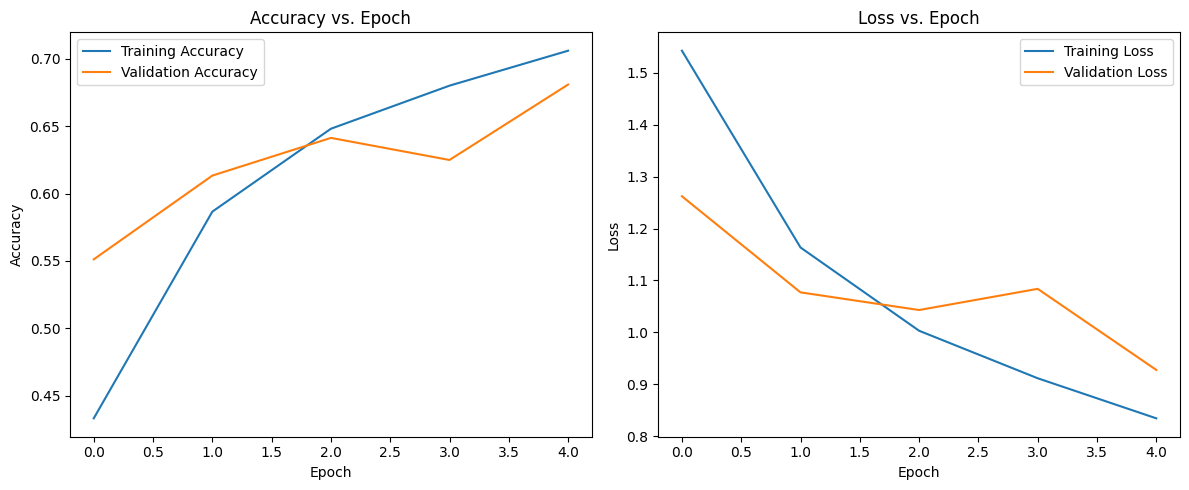

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


PART D: PERFORMANCE ANALYSIS

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step
Classification Accuracy: 0.6839


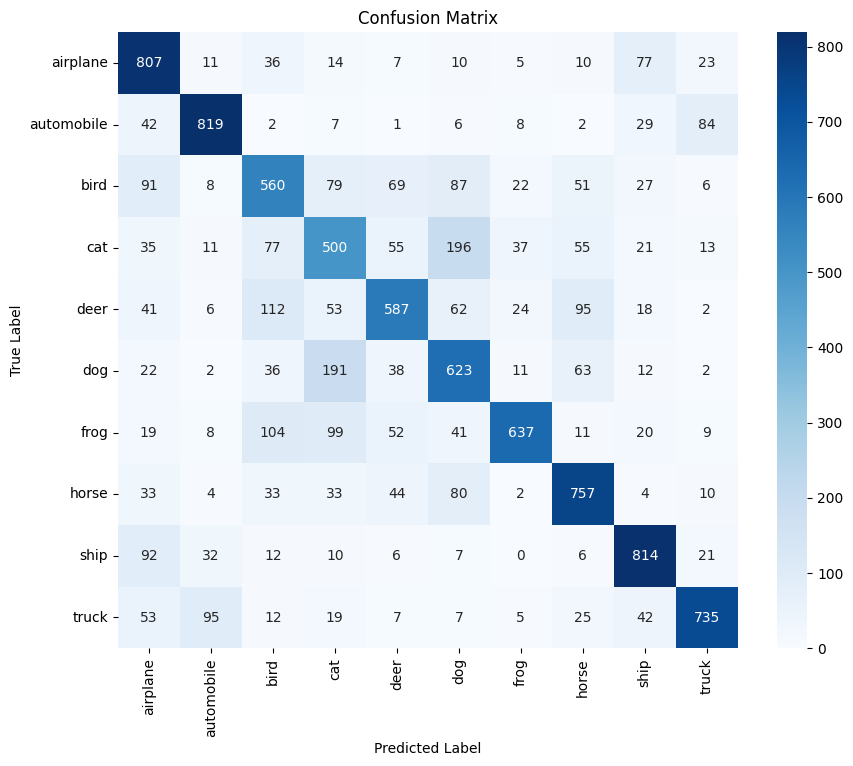


Classification Report:
              precision    recall  f1-score   support

    airplane       0.65      0.81      0.72      1000
  automobile       0.82      0.82      0.82      1000
        bird       0.57      0.56      0.56      1000
         cat       0.50      0.50      0.50      1000
        deer       0.68      0.59      0.63      1000
         dog       0.56      0.62      0.59      1000
        frog       0.85      0.64      0.73      1000
       horse       0.70      0.76      0.73      1000
        ship       0.77      0.81      0.79      1000
       truck       0.81      0.73      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict probabilities for the test set
y_pred_probs = model.predict(x_test)
# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
# Get true class labels from one-hot encoded y_test
y_true_classes = np.argmax(y_test, axis=1)

# Classification Accuracy (already calculated as Test Accuracy)
print(f'Classification Accuracy: {test_accuracy:.4f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report (provides precision, recall, f1-score)
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

Correctly Classified Samples:


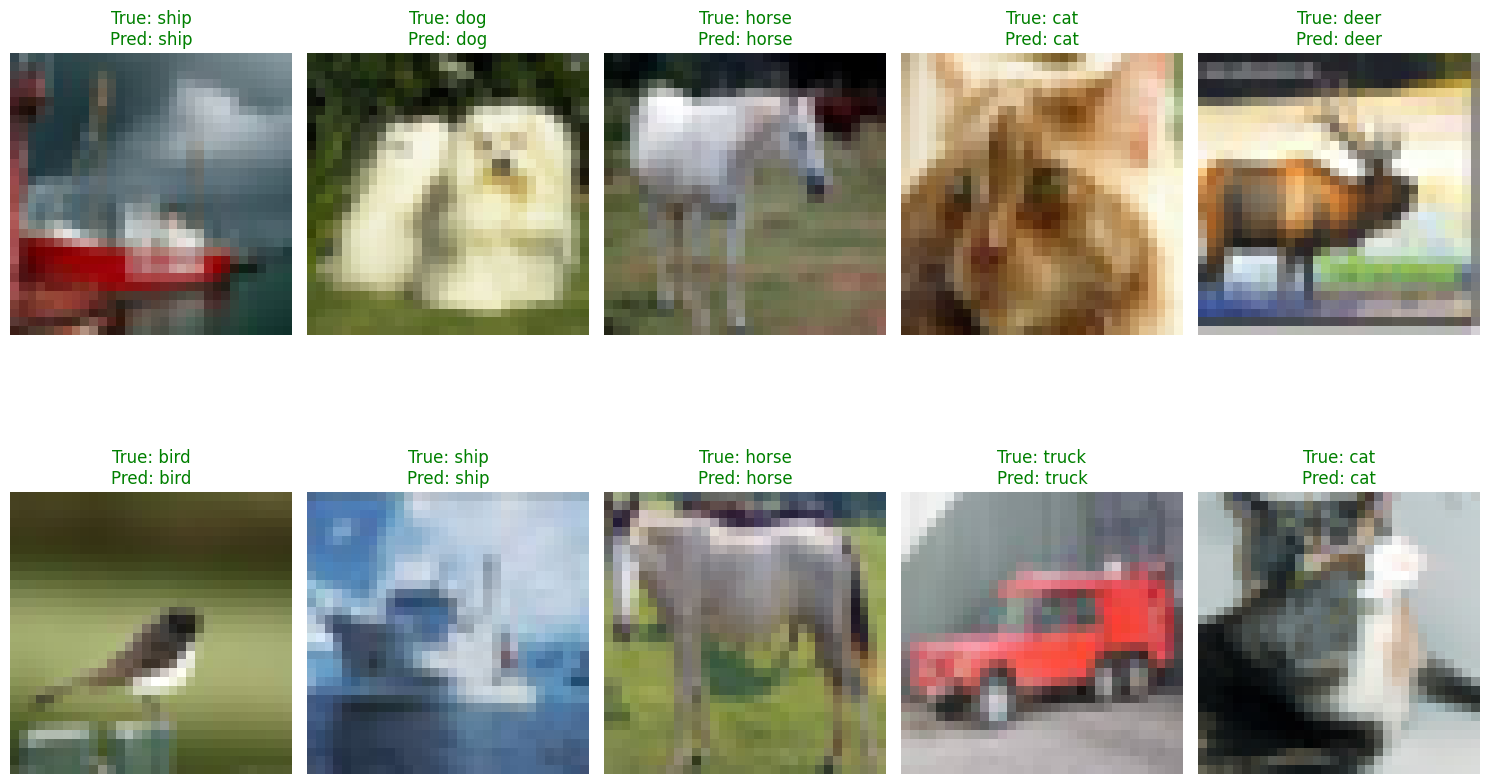


Misclassified Samples:


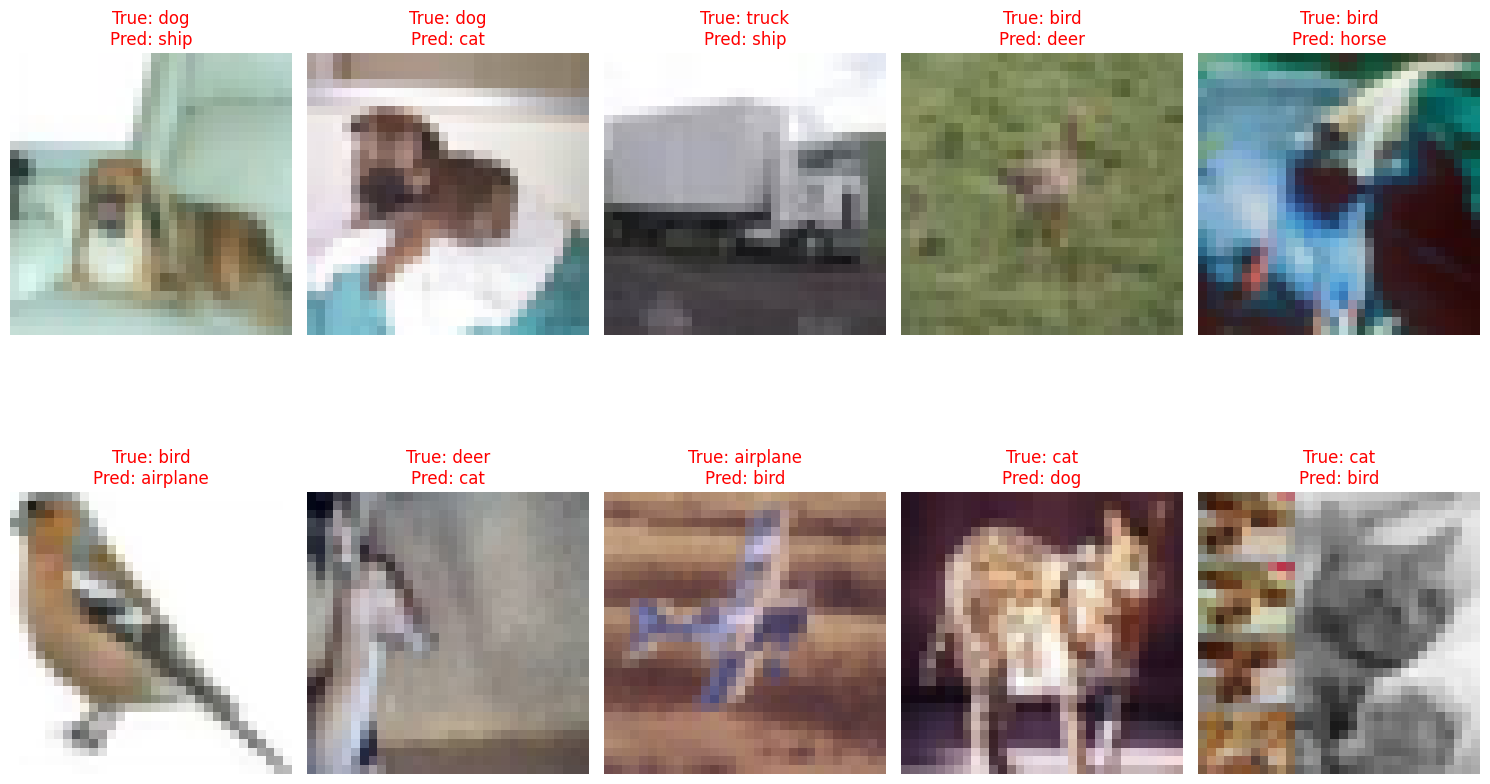

In [18]:
def plot_sample_images(images, true_labels, pred_labels, class_names, num_samples=10):
    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(f'True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}',
                  color='green' if true_labels[i] == pred_labels[i] else 'red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Get indices of correctly and incorrectly classified images
correct_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

# Sample correctly classified images
print('Correctly Classified Samples:')
sample_correct_indices = np.random.choice(correct_indices, 10, replace=False)
plot_sample_images(x_test[sample_correct_indices],
                   y_true_classes[sample_correct_indices],
                   y_pred_classes[sample_correct_indices],
                   class_names)

# Sample misclassified images
print('\nMisclassified Samples:')
sample_incorrect_indices = np.random.choice(incorrect_indices, 10, replace=False)
plot_sample_images(x_test[sample_incorrect_indices],
                   y_true_classes[sample_incorrect_indices],
                   y_pred_classes[sample_incorrect_indices],
                   class_names)